#JOCELYNE GONZÁLEZ HERNÁNDEZ

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

In [ ]:
df = pd.read_csv("dataset_proyecto.csv")
df

,Run,Base_Cake,Desiccator,T_C,RH_pct,RH_Sensor,Initial_g,Final_g,Time_min,Pct_Change,Run_Global
0,1,A,4,24,80,RH03,2.398990,2.638717,300,9.860415,1
1,2,A,18,24,80,RH03,2.488669,2.464012,480,-1.136036,2
2,3,A,17,24,80,RH03,2.340974,2.229033,360,-4.410898,3
3,4,A,20,24,80,RH03,2.427698,2.370022,480,-2.734284,4
4,5,A,19,24,80,RH03,2.401589,2.610692,1440,8.764906,5
...,...,...,...,...,...,...,...,...,...,...,...
1339,20,B,3,24,56,RH03,2.392938,2.762250,4320,15.215018,1340
1340,21,B,2,24,33,RH04,2.386487,2.742326,2160,14.807532,1341
1341,22,B,2,24,33,RH04,2.353268,2.659320,1440,12.981177,1342
1342,23,B,1,24,11,RH04,2.389806,2.777260,6480,16.274863,1343


- Run: Número de ejecución de la prueba (contador local).
- Run_Global: Número de identificación único y global para el experimento.
- Desiccator: Identificador del contenedor o desecador utilizado.
- RH_Sensor: Identificador del sensor de humedad específico usado.
- Base_Cake: Tipo de formulación
- T_C: Temperatura ambiente durante la prueba (en grados Celsius).
- RH_pct: Porcentaje de Humedad Relativa a la que se expuso la muestra.
- Time_min: Duración del experimento (en minutos).
- Initial_g: Peso de la muestra al inicio (gramos).
- Final_g: Peso de la muestra al final (gramos).
- Pct_Change: Cambio porcentual de peso (cuánta humedad absorbió o perdió).

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Run         1344 non-null   int64  
 1   Base_Cake   1344 non-null   object 
 2   Desiccator  1344 non-null   int64  
 3   T_C         1344 non-null   int64  
 4   RH_pct      1344 non-null   int64  
 5   RH_Sensor   1344 non-null   object 
 6   Initial_g   1344 non-null   float64
 7   Final_g     1344 non-null   float64
 8   Time_min    1344 non-null   int64  
 9   Pct_Change  1344 non-null   float64
 10  Run_Global  1344 non-null   int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 115.6+ KB


In [ ]:
#Verificar si hay datos faltantes o infinitos}
df.isnull().sum()

,0
Run,0
Base_Cake,0
Desiccator,0
T_C,0
RH_pct,0
RH_Sensor,0
Initial_g,0
Final_g,0
Time_min,0
Pct_Change,0


In [ ]:
#Verificar si hay datos infinitos
is_inf = df.isin([np.inf, -np.inf]).any()
is_inf[is_inf]

,0


In [ ]:
drop_cols = ['Run','Run_Global','T_C']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
# Visualizar nulos
df.isna().sum()

,0
Base_Cake,0
Desiccator,0
RH_pct,0
RH_Sensor,0
Initial_g,0
Final_g,0
Time_min,0
Pct_Change,0


##CATEGORIZAR

In [ ]:
df['Base_Cake'] = df['Base_Cake'].map({'A': 0, 'B': 1})

In [ ]:
#Volver Desicator de tipo object /categorica
df['Desiccator'] = df['Desiccator'].astype('object')

In [ ]:
#Valores unicos de Desiccator
df['Desiccator'].unique()

array([4, 18, 17, 20, 19, 7, 3, 2, 1], dtype=object)

In [ ]:
#Categorizar Desiccator
df['Desiccator'] = df['Desiccator'].astype(int)

df['Desiccator'] = df['Desiccator'].map({
    1: 0,
    2: 1,
    3: 2,
    4: 3,
    7: 4,
    17: 5,
    18: 6,
    19: 7,
    20: 8
})


In [ ]:
#Valores unicos de Desiccator
df['RH_Sensor'].unique()

array(['RH03', 'RH02', 'RH01', 'RH04'], dtype=object)

In [ ]:
#Cateogrizar RH_Sensor
df['RH_Sensor'] = df['RH_Sensor'].map({
    'RH01': 0,
    'RH02': 1,
    'RH03': 2,
    'RH04': 3
})


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Base_Cake   1344 non-null   int64  
 1   Desiccator  1344 non-null   int64  
 2   RH_pct      1344 non-null   int64  
 3   RH_Sensor   1344 non-null   int64  
 4   Initial_g   1344 non-null   float64
 5   Final_g     1344 non-null   float64
 6   Time_min    1344 non-null   int64  
 7   Pct_Change  1344 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 84.1 KB


In [ ]:
df.describe()

,Base_Cake,Desiccator,RH_pct,RH_Sensor,Initial_g,Final_g,Time_min,Pct_Change
count,1344.000000,1344.000000,1344.000000,1344.000000,1344.000000,1344.000000,1344.000000,1344.000000
mean,0.500744,4.791667,68.333333,1.416667,2.417845,2.659067,1922.172619,9.974729
std,0.500186,2.662118,22.205610,1.077305,0.039456,0.220876,1434.112373,8.929285
min,0.000000,0.000000,11.000000,0.000000,2.274957,1.942376,5.000000,-19.141261
25%,0.000000,2.750000,74.000000,0.000000,2.391951,2.507806,720.000000,3.846160
50%,1.000000,5.000000,80.000000,2.000000,2.418427,2.658602,1440.000000,9.836517
75%,1.000000,7.250000,80.000000,2.000000,2.443356,2.808738,2880.000000,15.970335
max,1.000000,8.000000,80.000000,3.000000,2.547674,3.407044,7920.000000,41.232696


In [ ]:
df

,Base_Cake,Desiccator,RH_pct,RH_Sensor,Initial_g,Final_g,Time_min,Pct_Change
0,0,3,80,2,2.398990,2.638717,300,9.860415
1,0,6,80,2,2.488669,2.464012,480,-1.136036
2,0,5,80,2,2.340974,2.229033,360,-4.410898
3,0,8,80,2,2.427698,2.370022,480,-2.734284
4,0,7,80,2,2.401589,2.610692,1440,8.764906
...,...,...,...,...,...,...,...,...
1339,1,2,56,2,2.392938,2.762250,4320,15.215018
1340,1,1,33,3,2.386487,2.742326,2160,14.807532
1341,1,1,33,3,2.353268,2.659320,1440,12.981177
1342,1,0,11,3,2.389806,2.777260,6480,16.274863


# 2. EXPLORACIÓN

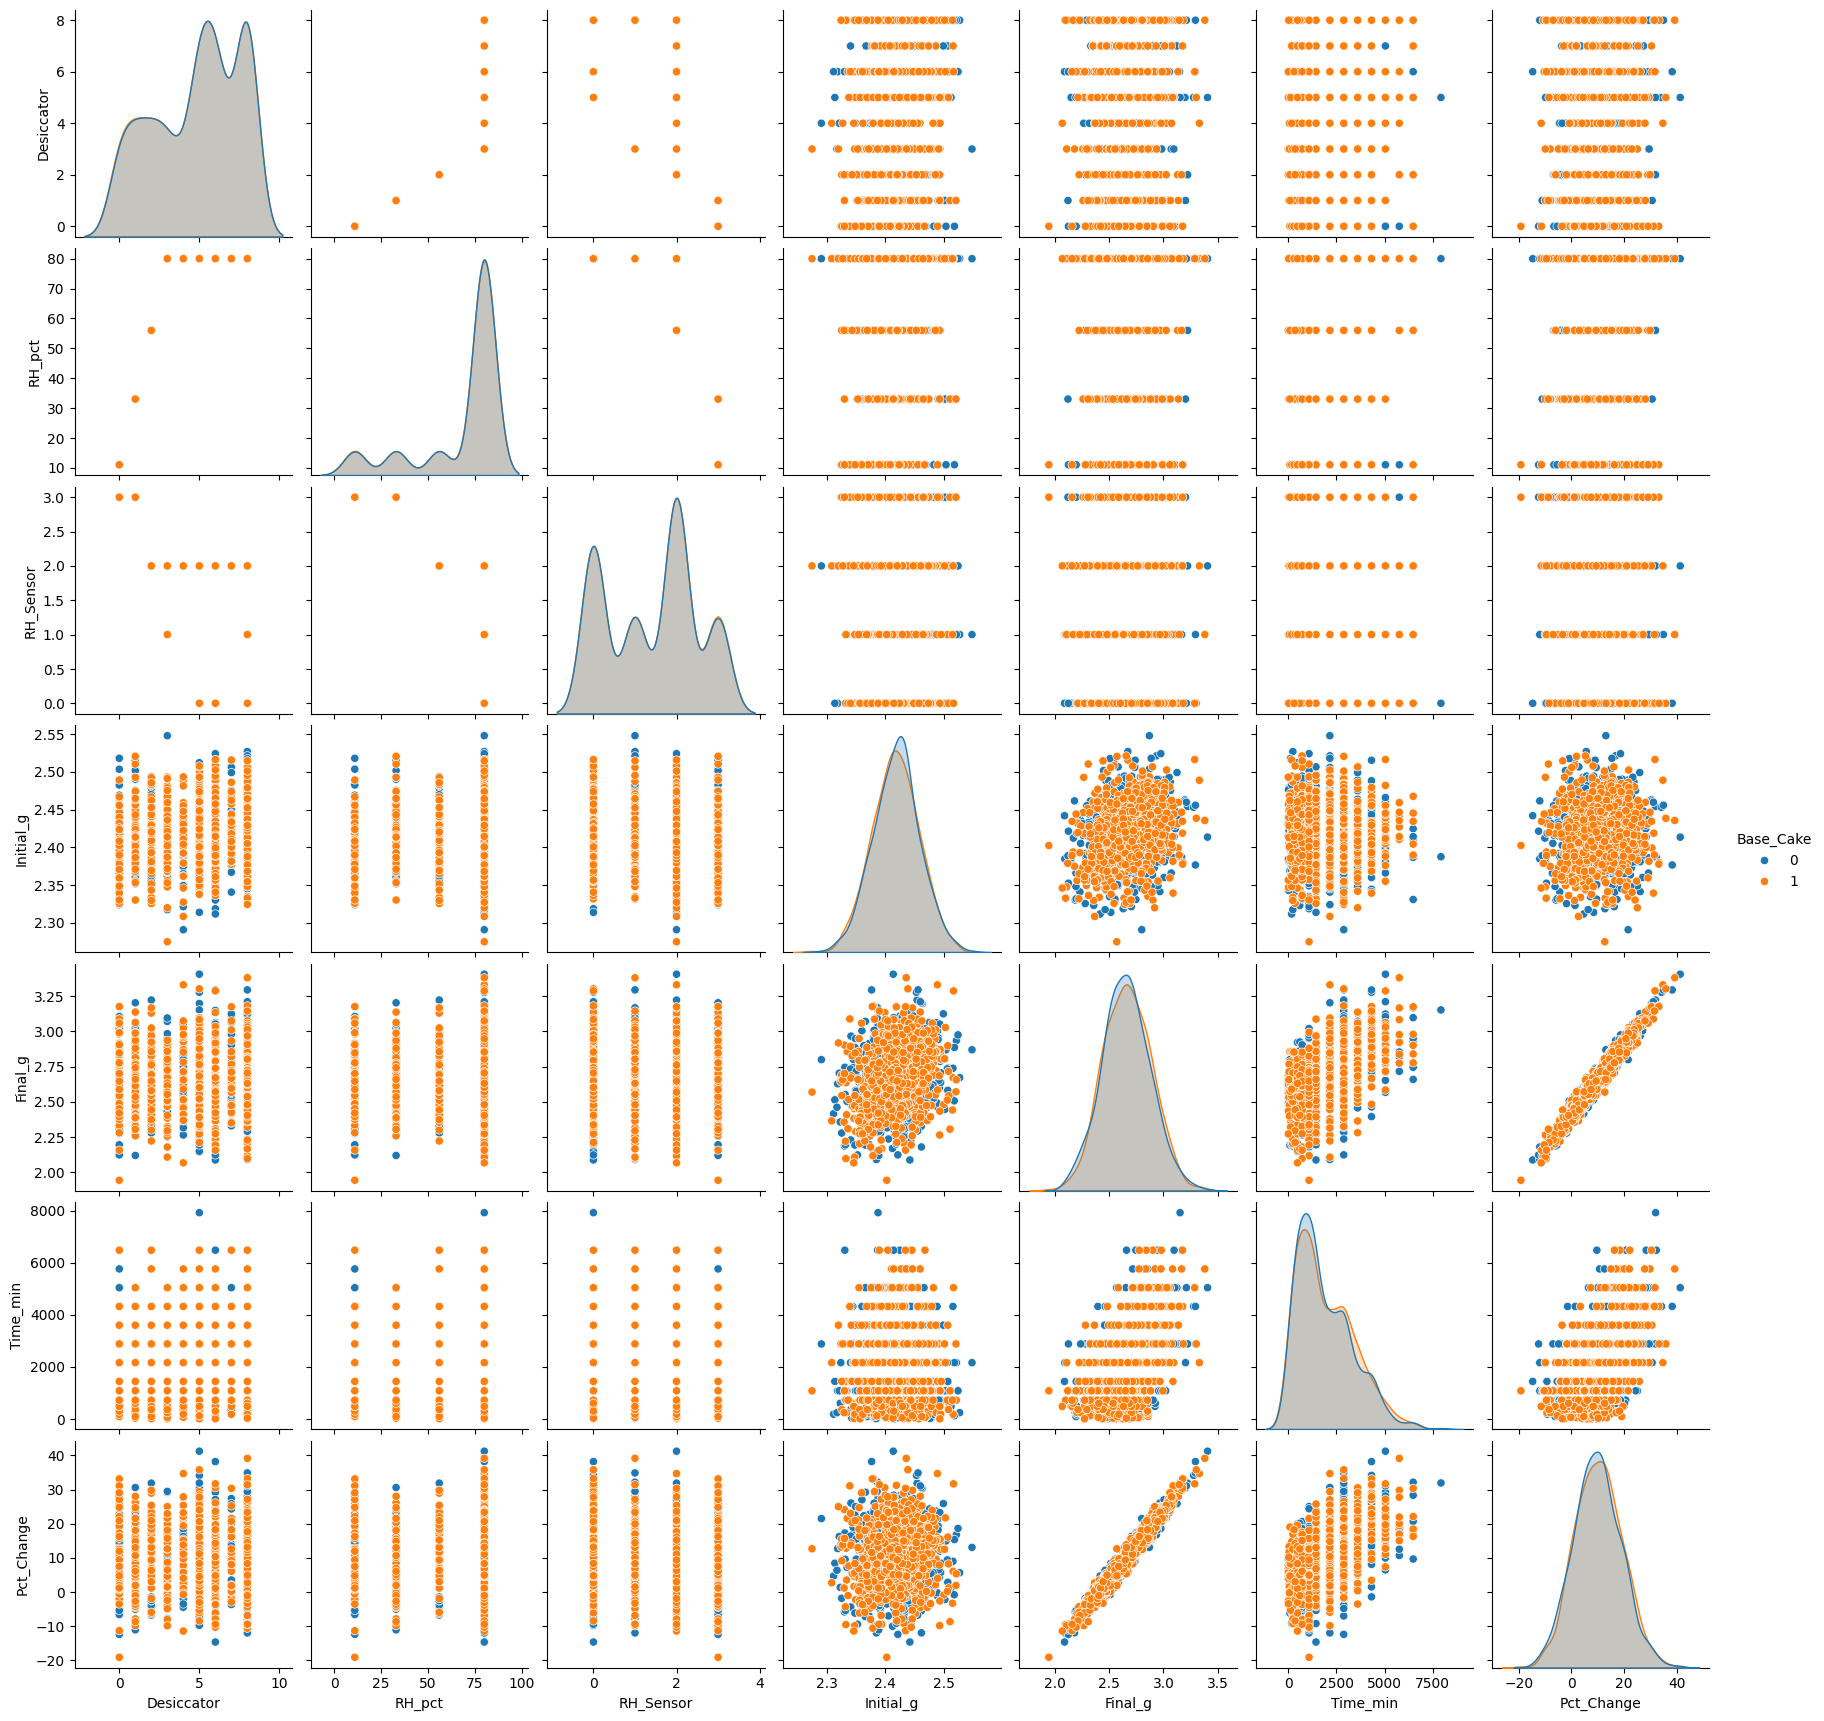

In [ ]:
#Haz un pairplot
sns.pairplot(df, hue='Base_Cake')
plt.show()

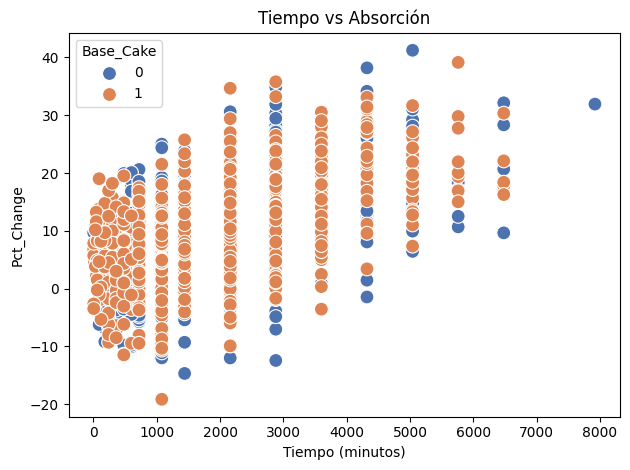

In [ ]:
# Gráfica C: Relación Tiempo vs Absorción (Scatter Plot)
sns.scatterplot(x='Time_min', y='Pct_Change', hue='Base_Cake', data=df, s=100, palette='deep')
plt.title('Tiempo vs Absorción')
plt.xlabel('Tiempo (minutos)')

plt.tight_layout()
plt.show()

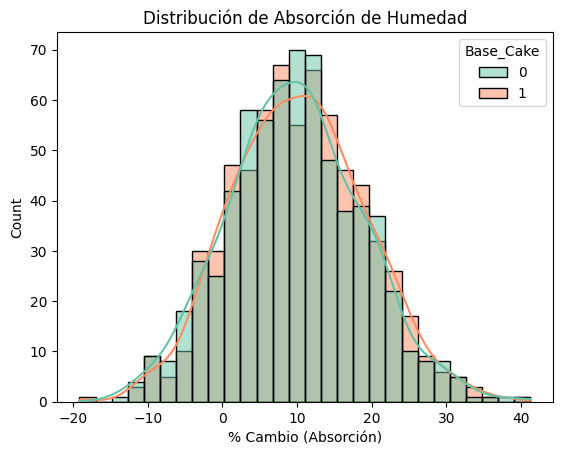

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Gráfica A: Distribución de la Variable Objetivo (Absorción) deferenciado por masas
sns.histplot(data=df, x='Pct_Change', kde=True, hue='Base_Cake', palette='Set2')
plt.title('Distribución de Absorción de Humedad')
plt.xlabel('% Cambio (Absorción)')
plt.show()

/tmp/ipython-input-962211068.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Base_Cake', y='Pct_Change', data=df, palette='Set2')


Text(0.5, 0, 'Tipo de Galleta')

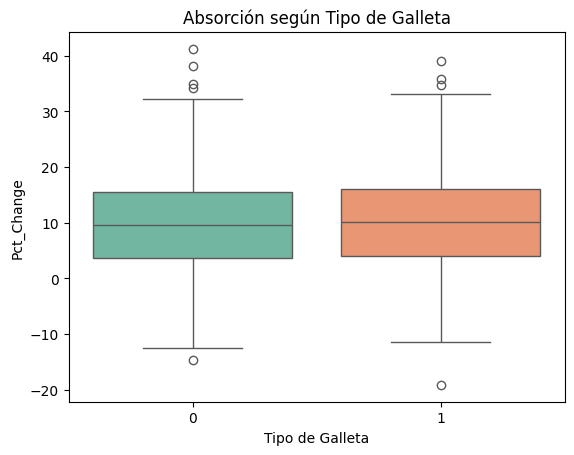

In [ ]:
# Gráfica B: Comparación por Tipo de Galleta (Boxplot)
sns.boxplot(x='Base_Cake', y='Pct_Change', data=df, palette='Set2')
plt.title('Absorción según Tipo de Galleta')
plt.xlabel('Tipo de Galleta')

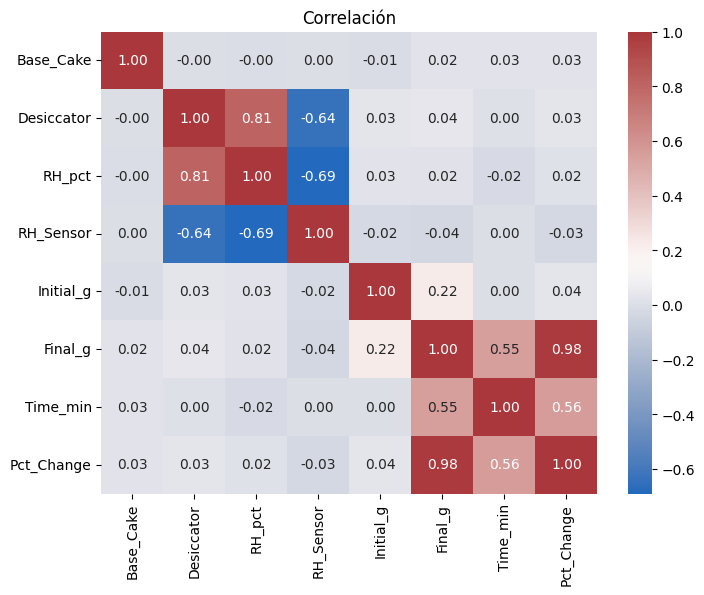

In [ ]:
# Matriz de correlación coherente
# df = df.drop(columns=['RH_Sensor','Desiccator']) # This line was commented out
# Use numeric_only=True to calculate correlation only for numeric columns.
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag")
plt.title("Correlación"); plt.show()

In [ ]:
#Imprime matriz de correlación
corr_matrix


,Base_Cake,Desiccator,RH_pct,RH_Sensor,Initial_g,Final_g,Time_min,Pct_Change
Base_Cake,1.000000,-0.002679,-0.003844,0.002188,-0.014992,0.024869,0.025788,0.028578
Desiccator,-0.002679,1.000000,0.812361,-0.638522,0.034059,0.039475,0.004192,0.034141
RH_pct,-0.003844,0.812361,1.000000,-0.689087,0.027795,0.020302,-0.016658,0.015679
RH_Sensor,0.002188,-0.638522,-0.689087,1.000000,-0.024308,-0.037930,0.003689,-0.034454
Initial_g,-0.014992,0.034059,0.027795,-0.024308,1.000000,0.223532,0.003155,0.035382
Final_g,0.024869,0.039475,0.020302,-0.037930,0.223532,1.000000,0.548617,0.981901
Time_min,0.025788,0.004192,-0.016658,0.003689,0.003155,0.548617,1.000000,0.562243
Pct_Change,0.028578,0.034141,0.015679,-0.034454,0.035382,0.981901,0.562243,1.000000


No hay una correlación lineal fuerte con Pct_Change. El comportamiento no es lineal, por eso se recurre Random Forest.

Decidí eliminar Initical_g porque estaba muy correlacionada con Final_g

También decidí eliminar Desiccator porque tiene alta relación con RH_pct y puede provocar redundancias, ya que el tipo de Desiccator esta asociado a un porcentaje de humedad, y lo que realmente importa son las condiciones física, el Desiccator solo es un identificador.

# MODELO BOSQUES DE REGRESIÓN

##Construcción del modelo

In [ ]:
X = df[['Base_Cake', 'RH_pct', 'RH_Sensor', 'Final_g', 'Time_min']]
y = df['Pct_Change']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse}")

RMSE: 2.0500209579255904


##Importancia de variables

In [ ]:
#Importancia de la variables
importances = regressor.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
print(importance_df)

     Feature  Importance
3    Final_g    0.985825
4   Time_min    0.007376
2  RH_Sensor    0.003153
1     RH_pct    0.001930
0  Base_Cake    0.001715


##Diagrama de Pareto

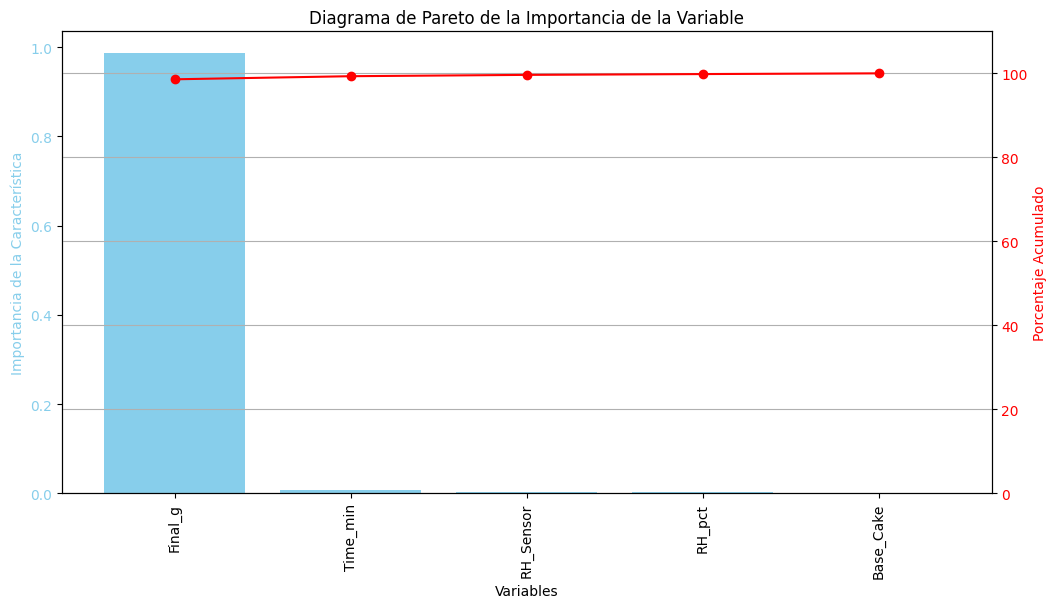

In [ ]:
feature_importances_sorted = importance_df.set_index('Feature')['Importance']

# Calculate cumulative percentage
cumulative_percentage = feature_importances_sorted.cumsum() / feature_importances_sorted.sum() * 100

# Create Pareto chart
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot for correlations
ax1.bar(feature_importances_sorted.index, feature_importances_sorted.values, color='skyblue')
ax1.set_ylabel('Importancia de la Característica', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xlabel('Variables')
plt.xticks(rotation=90)

# Line plot for cumulative percentage
ax2 = ax1.twinx()
ax2.plot(feature_importances_sorted.index, cumulative_percentage, color='red', marker='o', linestyle='-')
ax2.set_ylabel('Porcentaje Acumulado', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Add title and grid
plt.title('Diagrama de Pareto de la Importancia de la Variable')
plt.grid(True)

# Show plot
plt.show()

##MODELO SIN PESOS INCIIAL Y FINAL

In [ ]:
X = df[['Base_Cake', 'RH_pct', 'RH_Sensor', 'Time_min']]
y = df['Pct_Change']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse}")

RMSE: 7.170496017780209


SE BUSCA UN RMSE PEQUEÑO PARA MEJOR AJUSTE

## Importancia de variables

In [ ]:
#Importancia de la variables
importances = regressor.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
print(importance_df)

     Feature  Importance
3   Time_min    0.763386
2  RH_Sensor    0.085078
1     RH_pct    0.077867
0  Base_Cake    0.073669


##Diagrama de Pareto

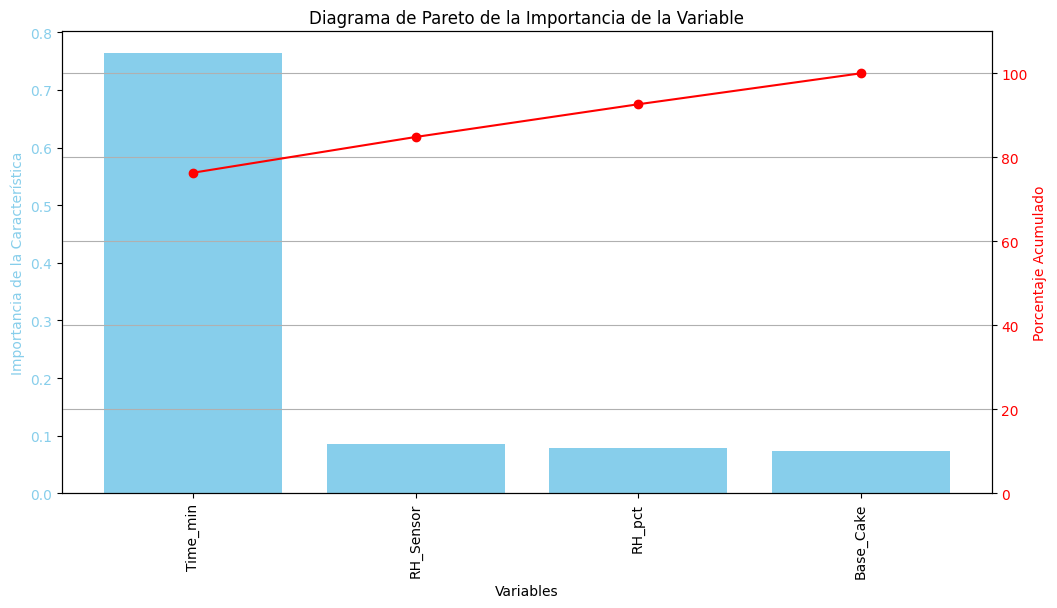

In [ ]:
feature_importances_sorted = importance_df.set_index('Feature')['Importance']

# Calculate cumulative percentage
cumulative_percentage = feature_importances_sorted.cumsum() / feature_importances_sorted.sum() * 100

# Create Pareto chart
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot for correlations
ax1.bar(feature_importances_sorted.index, feature_importances_sorted.values, color='skyblue')
ax1.set_ylabel('Importancia de la Característica', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xlabel('Variables')
plt.xticks(rotation=90)

# Line plot for cumulative percentage
ax2 = ax1.twinx()
ax2.plot(feature_importances_sorted.index, cumulative_percentage, color='red', marker='o', linestyle='-')
ax2.set_ylabel('Porcentaje Acumulado', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Add title and grid
plt.title('Diagrama de Pareto de la Importancia de la Variable')
plt.grid(True)

# Show plot
plt.show()

Tomé la decisión de eliminar la variable categórica RH_Sensor del modelo predictivo tras detectar que presentaba una colinealidad alta con los rangos de la variable física RH_pct (Humedad Relativa). Alguno esnsores fueron utilizados exclusivamente para rangos específicos de humedad (ej. RH04 solo para <33%), lo que provocaría que el modelo aprendiera sesgos instrumentales en lugar de la relación física causal.

In [ ]:
X = df[['Base_Cake', 'RH_pct','Time_min']]
y = df['Pct_Change']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

regressor = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
regressor.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, random_state=42)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse}")

RMSE: 7.140960520817453


In [ ]:
#Importancia de la variables
importances = regressor.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
print(importance_df)

     Feature  Importance
2   Time_min    0.832067
1     RH_pct    0.104160
0  Base_Cake    0.063773


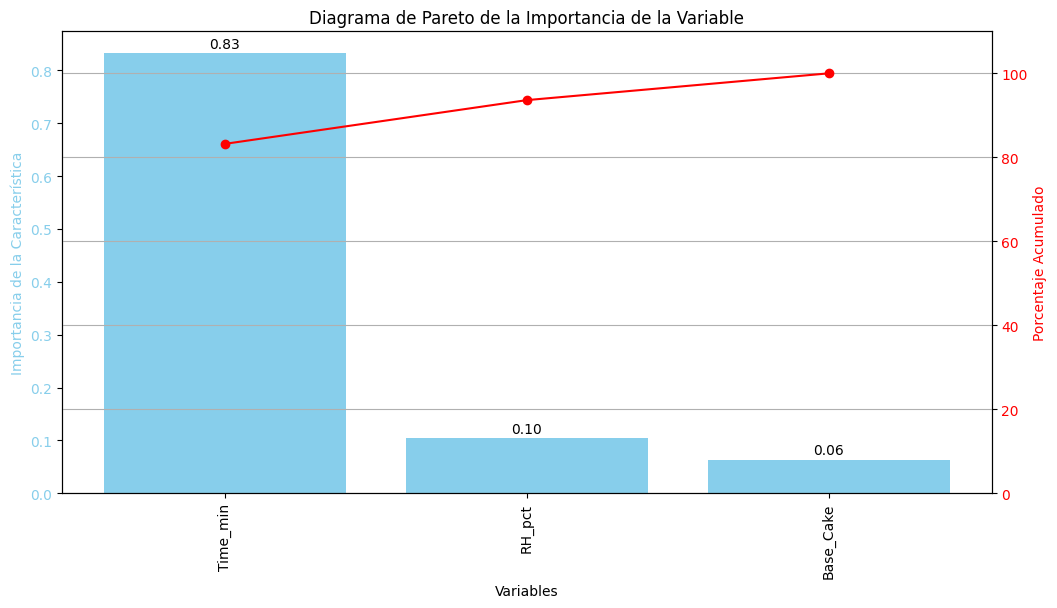

In [ ]:
feature_importances_sorted = importance_df.set_index('Feature')['Importance']

# Calculate cumulative percentage
cumulative_percentage = feature_importances_sorted.cumsum() / feature_importances_sorted.sum() * 100

# Create Pareto chart
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot for correlations
ax1.bar(feature_importances_sorted.index, feature_importances_sorted.values, color='skyblue')
ax1.set_ylabel('Importancia de la Característica', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xlabel('Variables')
plt.xticks(rotation=90)

# Add importance labels on top of the bars
for i, v in enumerate(feature_importances_sorted.values):
    ax1.text(i, v + 0.005, f'{v:.2f}', color='black', ha='center', va='bottom')

# Line plot for cumulative percentage
ax2 = ax1.twinx()
ax2.plot(feature_importances_sorted.index, cumulative_percentage, color='red', marker='o', linestyle='-')
ax2.set_ylabel('Porcentaje Acumulado', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Add title and grid
plt.title('Diagrama de Pareto de la Importancia de la Variable')
plt.grid(True)

# Show plot
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Definir el modelo base (Random Forest)
bosque = RandomForestRegressor(random_state=42)

# 2. Definir la "Rejilla" para Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],      # Número de árboles (Clave en Random Forest)
    'max_depth': [5, 10, None],          # Profundidad
    'min_samples_split': [2, 5, 10],     # Mínimo para dividir
    'min_samples_leaf': [2, 4, 6],       # Mínimo en hoja
    'max_features': ['sqrt', 'log2', None] # Variables por árbol
}

# 3. Configurar la búsqueda
grid_search = GridSearchCV(estimator=bosque, param_grid=param_grid,
                           cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)

# 4. Entrenar
print("Buscando los mejores parámetros para el Bosque...")
grid_search.fit(X_train, y_train)

# 5. Resultados
mejor_modelo = grid_search.best_estimator_
print(f"\nMejores Parámetros: {grid_search.best_params_}")

# 6. Evaluar
y_pred_opt = mejor_modelo.predict(X_test)
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_opt))
r2_opt = r2_score(y_test, y_pred_opt)

print(f"\n--- RESULTADOS RANDOM FOREST OPTIMIZADO ---")
print(f"RMSE: {rmse_opt:.4f}")
print(f"R2: {r2_opt:.4f}")

Buscando los mejores parámetros para el Bosque...

Mejores Parámetros: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}

--- RESULTADOS RANDOM FOREST OPTIMIZADO ---
RMSE: 6.9060
R2: 0.3306


#RESULTADOS

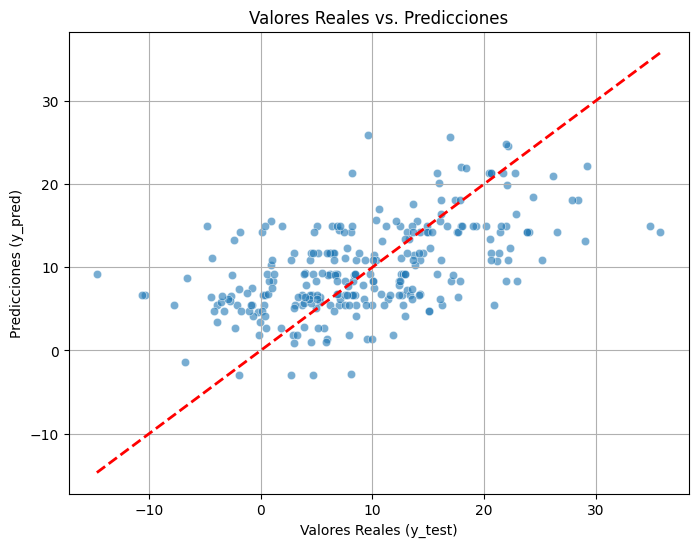

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales (y_test)')
plt.ylabel('Predicciones (y_pred)')
plt.title('Valores Reales vs. Predicciones del Random Forest')
plt.grid(True)
plt.show()

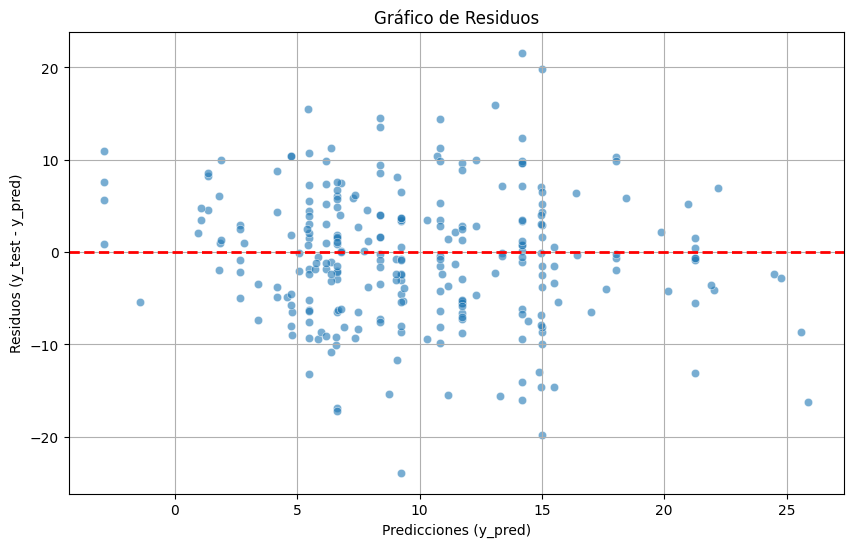

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular residuals
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicciones (y_pred)')
plt.ylabel('Residuos (y_test - y_pred)')
plt.title('Gráfico de Residuos')
plt.grid(True)
plt.show()

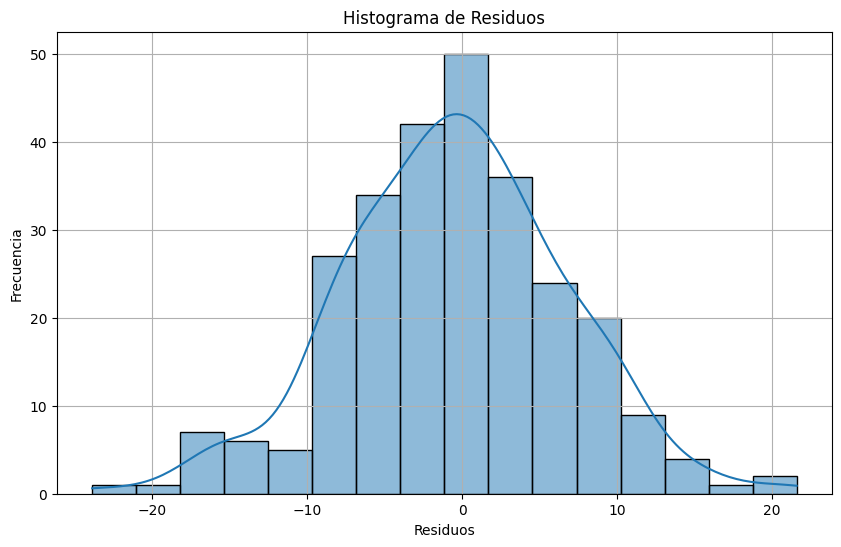

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma de los residuos
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Histograma de Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()